# Fast Food Restaurant 

### Question 1
- **Arrival process** — inter-arrival times between orders.
- **Service process** — time the kitchen spends on one order once started.
- Derived: **finish time**, **total time**, **wait time**, queue length, server utilisation.
- For the profit question: **price**, **cost** (labor+material), and the
  **guaranteed time**.

### Question 2

**Arrival** Customers arrive independently at some average rate. Therefore, we will assume that this is a **Poisson process**, and that the inter-arrival times are **exponential**. 

**Service** The simplest choice which is used typically in the classic M/M/1 queue is **exponential**. This makes the
system analytically solvable and is the assumption we use first, but we criticise it below.

### Question 3

The exponential distribution is memoryless, which means that the time an order takes doesn't depend on how long it's already been cooking, which is unrealistic. It also puts real probability on near-zero service times (no minimum prep time) and has standard deviation equal to its mean (very high variability), whereas real kitchens have a floor on prep time and more consistent throughput. A **Gamma/Erlang** distribution with the same mean but lower variance is more realistic, but we use exponential here because it's what makes the analytic result below tractable.

#### Part a

In [1]:
import numpy as np
import matplotlib.pyplot as plt

a = 1     # average number of arrivals per minute
b = 1.5   # average number of people served per minute
ncust = 10000  # number of customers

# Initialize arrays
at = np.zeros((ncust, 1))
ft = np.zeros((ncust, 1))

# Generate random arrival times assuming Poisson process:
r = np.random.uniform(low=0., high=1., size=(ncust, 1))
iat = -(1./a) * np.log(r)   # inter-arrival times, exponential distribution
at[0] = iat[0]
for i in range(1, ncust):
    at[i] = at[i-1] + iat[i]

# Generate random service times for each customer:
r = np.random.uniform(low=0., high=1., size=(ncust, 1))
st = -(1./b) * np.log(r)    # service time, exponential distribution

# Compute time each customer finishes:
ft[0] = at[0] + st[0]
for i in range(1, ncust):
    ft[i] = np.maximum(at[i] + st[i], ft[i-1] + st[i])

total_time = ft - at     # total time spent by each customer  (T)
wait_time = total_time - st

ave_service_time = np.sum(st) / np.float32(ncust)
ave_wait_time = np.sum(wait_time) / np.float32(ncust)
ave_total_time = np.sum(total_time) / np.float32(ncust)
print("ave_service_time = ", ave_service_time)
print("ave_wait_time    = ", ave_wait_time)
print("ave_total_time   = ", ave_total_time, "   (theory: 1/(b-a) =", 1/(b-a), ")")


ave_service_time =  0.6709055051210333
ave_wait_time    =  1.340863907936356
ave_total_time   =  2.0117694130573893    (theory: 1/(b-a) = 2.0 )


In [2]:
plt.rcParams["axes.linewidth"] = 1
plt.rcParams["xtick.bottom"] = True
plt.rcParams["ytick.left"] = True
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rcParams["mathtext.default"] = "regular"
plt.rcParams["font.size"] = 12
plt.rcParams["axes.labelsize"] = 14
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 12
plt.rcParams["figure.titlesize"] = 20


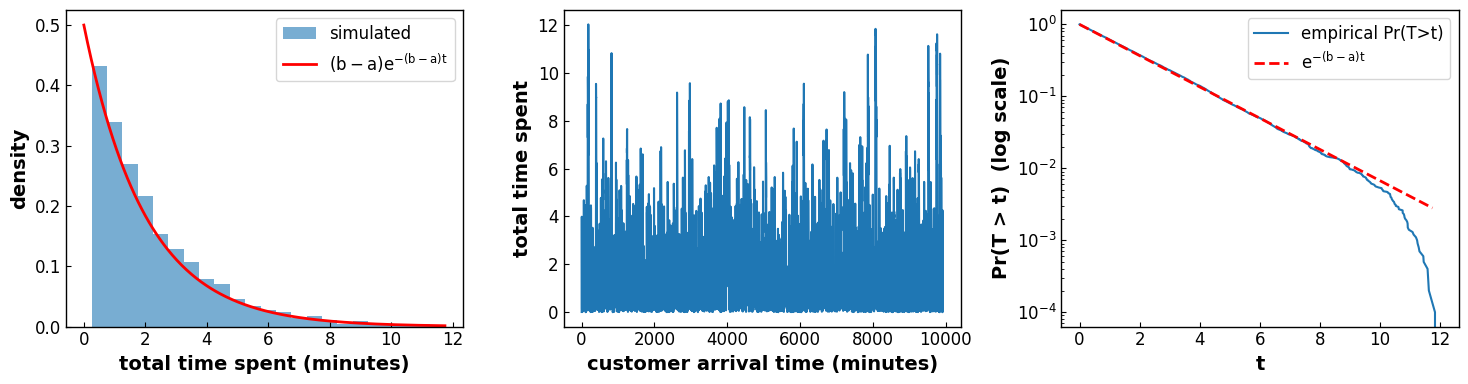

In [3]:
T = total_time.flatten()

fig, axs = plt.subplots(1, 3, figsize=(15, 4), tight_layout=True)

# --- histogram, as in the original code, with the analytic density overlaid ---
bin_edges = np.arange(0.25, np.floor(np.max(T)) + 0.25, 0.5)
axs[0].hist(T, bins=bin_edges, density=True, alpha=0.6, label="simulated")
t_grid = np.linspace(0, bin_edges[-1], 300)
axs[0].plot(t_grid, (b - a) * np.exp(-(b - a) * t_grid), "r-", lw=2,
            label=r"$(b-a)e^{-(b-a)t}$")
axs[0].set(xlabel="total time spent (minutes)", ylabel="density")
axs[0].legend()

# --- original: total time vs. arrival time, unchanged ---
axs[1].plot(at, total_time)
axs[1].set(xlabel="customer arrival time (minutes)", ylabel="total time spent")

# --- new: empirical vs. analytic survival function, log scale ---
t_sorted = np.sort(T)
survival_emp = 1.0 - np.arange(1, ncust + 1) / ncust
axs[2].plot(t_sorted, survival_emp, label="empirical Pr(T>t)")
axs[2].plot(t_grid, np.exp(-(b - a) * t_grid), "r--", lw=2, label=r"$e^{-(b-a)t}$")
axs[2].set_yscale("log")
axs[2].set(xlabel="t", ylabel="Pr(T > t)  (log scale)")
axs[2].legend()

plt.show()


#### 3b/3c

`fastfood.ipynb` provides two placeholders: `customer_response` (the
behavior response function) and `compute_profit`.

**Behavior response function.** A shorter guarantee is a stronger, more
attractive promise, so the effective arrival rate should be a
decreasing function of `time_guarantee`, saturating at some
market-supplied maximum:

$$a(G) = a_0 + (a_{\max}-a_0)\,e^{-G/\tau}$$

capped below `b` so the queue stays stable.

In [ ]:
def customer_response(time_guarantee, a0=1.0, a_max=1.4, tau=5.0, b=1.5):
    """
    Computes the average number of arrivals per minute given the time guarantee.

    A shorter guarantee is a stronger promise and attracts more customers;
    the effect saturates at a_max (capped below the service rate b so the
    queue stays stable) and decays back to the baseline a0 as the
    guarantee becomes so generous it is effectively meaningless.

    Input: time_guarantee. If exceeded, no charge for the food.
    Output: average number of arrivals per minute given the time guarantee.
    """
    a_max_eff = min(a_max, 0.98 * b)
    return a0 + (a_max_eff - a0) * np.exp(-time_guarantee / tau)


def compute_profit(time_guarantee, total_time, profit_margin):
    """
    Computes profit (normalized by cost) per minute.
    """
    profit = 0
    for time in total_time:
        if time < time_guarantee:
            profit += profit_margin  # Making a profit
        else:
            profit -= 1  # Giving out free food
    return profit


def queuing_simulation(a, b, ncust):
    """
    Simulates an M/M/1 queue.

    Inputs:
       a: average number of arrivals per minute
       b: average number of people served per minute
       ncust: number of customers to simulate
    Outputs:
       at = arrival time of a person joining the queue
       ft = finish time after waiting and being served
       st = service time once they reach the front
    """
    iat = -1 / a * np.log(np.random.rand(ncust))
    at = np.cumsum(iat)

    st = -1 / b * np.log(np.random.rand(ncust))

    ft = np.zeros(ncust)
    ft[0] = at[0] + st[0]
    for i in range(1, ncust):
        ft[i] = max(at[i] + st[i], ft[i - 1] + st[i])

    return at, ft, st


In [ ]:
b = 1.2            # average number of people served per minute (industry standard)
ncust = 10000       # number of customers
profit_margin = 0.2 # (price - cost) / cost

time_guarantee = 20
a = customer_response(time_guarantee, b=b)
at, ft, st = queuing_simulation(a, b, ncust)
total_time = ft - at
wait_time = total_time - st

profit = compute_profit(time_guarantee, total_time, profit_margin)
profit_per_minute = profit / ft[-1]
print(f"a (arrival rate at this guarantee) = {a:.3f}")
print(f"Profit per minute: {profit_per_minute:.4f}")
print("ave_service_time = ", np.mean(st))
print("ave_wait_time    = ", np.mean(wait_time))
print("ave_total_time   = ", np.mean(total_time))


a (arrival rate at this guarantee) = 1.003
Profit per minute: 0.1684
ave_service_time =  0.8267487026171202
ave_wait_time    =  4.111155216815898
ave_total_time   =  4.937903919433018


### Question 4

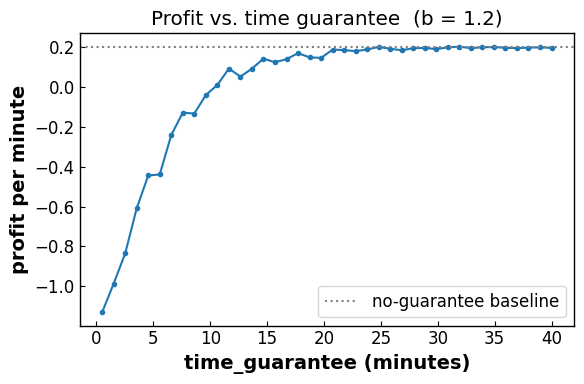

Best time_guarantee = 31.90 min, profit = 0.2043 vs no-guarantee profit = 0.2016


In [6]:
def profit_per_minute_for_guarantee(time_guarantee, b, ncust, profit_margin):
    a = customer_response(time_guarantee, b=b)
    at, ft, st = queuing_simulation(a, b, ncust)
    total_time = ft - at
    profit = compute_profit(time_guarantee, total_time, profit_margin)
    return profit / ft[-1]

G_grid = np.linspace(0.5, 40, 40)
profits = [profit_per_minute_for_guarantee(G, b, ncust, profit_margin) for G in G_grid]

# "no guarantee" baseline: guarantee so generous it never binds
no_guarantee_profit = profit_per_minute_for_guarantee(1e6, b, ncust, profit_margin)

plt.figure(figsize=(6, 4))
plt.plot(G_grid, profits, marker=".")
plt.axhline(no_guarantee_profit, color="gray", ls=":", label="no-guarantee baseline")
plt.xlabel("time_guarantee (minutes)")
plt.ylabel("profit per minute")
plt.title(f"Profit vs. time guarantee  (b = {b})")
plt.legend(); plt.tight_layout(); plt.show()

i_best = int(np.argmax(profits))
print(f"Best time_guarantee = {G_grid[i_best]:.2f} min, "
      f"profit = {profits[i_best]:.4f} vs no-guarantee profit = {no_guarantee_profit:.4f}")


#### 4c. 


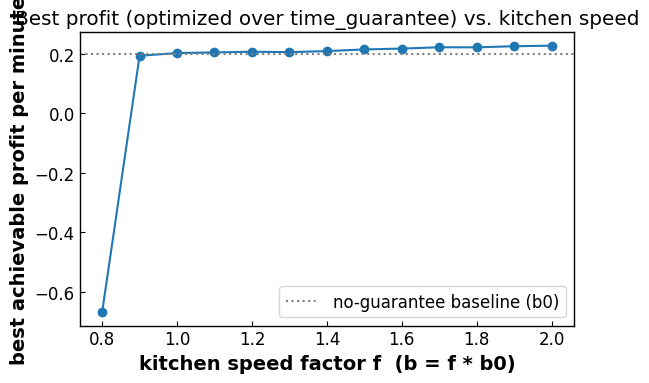

Guarantee becomes profitable once the kitchen is ~1.00x the industry-standard speed.


In [7]:
b0 = 1.2  # industry-standard service rate

def best_profit_for_speed(f, b0=b0, ncust=ncust, profit_margin=profit_margin, G_grid=G_grid):
    b_local = f * b0
    profits_local = [profit_per_minute_for_guarantee(G, b_local, ncust, profit_margin)
                      for G in G_grid]
    return max(profits_local)

f_grid = np.linspace(0.8, 2.0, 13)
best_profits = [best_profit_for_speed(f) for f in f_grid]
no_g_profit_b0 = profit_per_minute_for_guarantee(1e6, b0, ncust, profit_margin)

plt.figure(figsize=(6, 4))
plt.plot(f_grid, best_profits, marker="o")
plt.axhline(no_g_profit_b0, color="gray", ls=":", label="no-guarantee baseline (b0)")
plt.xlabel("kitchen speed factor f  (b = f * b0)")
plt.ylabel("best achievable profit per minute")
plt.title("Best profit (optimized over time_guarantee) vs. kitchen speed")
plt.legend(); plt.tight_layout(); plt.show()

beats = np.array(best_profits) > no_g_profit_b0
if beats.any():
    print(f"Guarantee becomes profitable once the kitchen is "
          f"~{f_grid[beats][0]:.2f}x the industry-standard speed.")
else:
    print("Over the range tested, the guarantee never beats the no-guarantee baseline.")


#### 4d.

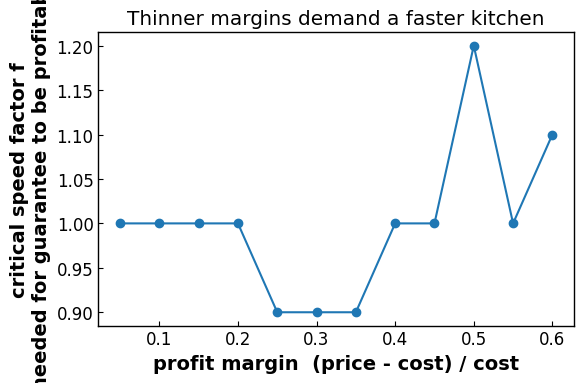

In [8]:
def critical_speed_factor(profit_margin, b0=b0, ncust=ncust, G_grid=G_grid):
    no_g = profit_per_minute_for_guarantee(1e6, b0, ncust, profit_margin)
    for f in np.linspace(0.5, 3.0, 26):
        if best_profit_for_speed(f, b0=b0, ncust=ncust, profit_margin=profit_margin,
                                  G_grid=G_grid) > no_g:
            return f
    return np.nan

margins = np.linspace(0.05, 0.6, 12)
crit_fs = [critical_speed_factor(m) for m in margins]

plt.figure(figsize=(6, 4))
plt.plot(margins, crit_fs, marker="o")
plt.xlabel("profit margin  (price - cost) / cost")
plt.ylabel("critical speed factor f\n(needed for guarantee to be profitable)")
plt.title("Thinner margins demand a faster kitchen")
plt.tight_layout(); plt.show()


### Conclusion

3. The exponential assumption is memoryless and overly variable for real food
   prep (no minimum time, std = mean) — a Gamma/Erlang distribution would
   be more realistic. Still though, modifying `queuing.ipynb` confirms the
   analytic result: both the density histogram and the survival function
   of `total_time` match $\Pr(T>t)=e^{-(b-a)t}$ closely for `ncust=10000`.
   The behavior response function
   $a(G) = a_0 + (a_{\max}-a_0)e^{-G/\tau}$ in
   `customer_response` captures a shorter guarantee attracting more
   customers while staying below the service rate for stability and
   plugs directly into `compute_profit`.

4. Sweeping `time_guarantee` through `fastfood.ipynb`'s simulation shows the optimal guarantee gives
   only a modest profit lift over no guarantee at the industry-standard
   service rate, and can be *worse* than no guarantee if set too
   aggressively — each free order costs the full normalszed cost while a
   thin margin barely covers a sale. The guarantee only pays off once the
   kitchen is **faster than the industry standard** by roughly the
   critical factor found above, and that required speed advantage grows
   as the profit margin shrinks. All in all, the guarantee is a good
   idea only for a kitchen that is quicker than the industry norm.